In [1]:
METHOD = "DIRICHLET"

# Dirichlet search algorithm

In [2]:
import os
import io
import random
import copy
import torch
import json
import pickle
import contextlib
import numpy as np
from operator import itemgetter
from ultralytics import YOLO 
from mylib import myutils
from mylib import simsettings
from mylib import simtools
from mylib import yolo_patch_softmax as _
from mylib import probtools
from constants import OBS_SCALE, CELL_SIDE, MAP_RESOLUTION, DISPLAY_STEP
from constants import AGENT_HEIGHT, AGENT_RADIUS 
from constants import MAX_ITER_COEF, CONFIDENCE_THRESHOLD, LOCATION_ERROR_THRESHOLD, PSEUDO_COUNT_THRESHOLD
from constants import NUM_CLASSES, DIRICHLET_PRIOR
from constants import ACTIONS
from constants import NUM_EPOCHS
from dotenv import load_dotenv
load_dotenv()

import habitat_sim
import habitat_sim.nav as nav
from habitat.utils.visualizations import maps
from habitat_sim.utils import common as utils

# Reload imported modules
%load_ext autoreload
%autoreload 2

# Load YOLO model
yolo_model = YOLO("yolo11x.pt")

# Initialize cuda:0 device
device = "cuda:0" if torch.cuda.is_available() else "cpu"
with contextlib.redirect_stdout(io.StringIO()):
    yolo_model = yolo_model.to(device)

PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring


In [4]:
# Load the JSON file for simulation
with open('simulation-data/simulations.json', 'r') as f:
    simulations = json.load(f)

# Simulation configuration 
simulation = simulations[56]
 
# Access its fields
SCENE = simulation["scene"]
TARGET_OBJECT = simulation["target_object"]
TARGET_OBJECT_ID = simulation["target_object_id"]
REAL_TARGET_LOCATION = simulation["target_object_location"]
INDEX = simulation["index"]

# Load the JSON file for RGB camera intrinsics
with open('simulation-data/camera-intrinsics.json', 'r') as f:
    intrinsics = json.load(f)

# Load bins per class
with open('simulation-data/object-classes-bins.json', 'r') as f:
    classes_bins = json.load(f)

# Load indoor objects
with open('simulation-data/indoor-objects.json', 'r') as f:
    data = json.load(f)
    indoor_objects = [list(item.values())[0] for item in data["indoor_classes"]]
    TARGET_OBJECT_CLASS_ID = indoor_objects.index(TARGET_OBJECT)

# Load Dirichlet priors
with open('simulation-data/dirichlet-alpha-priors-augmented.pkl', 'rb') as f:
    dirichlet_priors = pickle.load(f)

# Simulator configuration
dataset_config_file = os.path.join(os.getenv("AI2THOR_DATA"), "ai2thor-hab.scene_dataset_config.json")
sim_settings = {
    "seed": 1,
    "dataset": dataset_config_file,  # Scene dataset
    "scene": SCENE,  # Scene path
    "width": 1024,  # Spatial resolution of the observations
    "height": int(1024*OBS_SCALE),
    "default_agent": 0,
    "sensor_height": AGENT_HEIGHT,  # Height of sensors in meters
    "color_sensor": True,  # RGB sensor
    "depth_sensor": True,  # Depth sensor
    "enable_physics": False,  # kinematics only
}
# Initialize the simulator
cfg = simsettings.make_cfg(sim_settings)
sim = habitat_sim.Simulator(cfg)

In [5]:
# Get the root node of the active scene graph
scene_root = sim.get_active_scene_graph().get_root_node()
scene_bb = scene_root.cumulative_bb
scene_dims = scene_bb.size()

# Define navmesh settings
navmesh_settings = simsettings.create_navmesh_settings(AGENT_HEIGHT, AGENT_RADIUS, max_climb=0.2, max_slope=45.0, include_static_objects=True)

# Recompute the navmesh for the current scene
sim.recompute_navmesh(sim.pathfinder, navmesh_settings)

# Generate the top-down map --> 1 cm per pixel
topdown_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=MAP_RESOLUTION, draw_border=True)
topdown_map, topdown_resolution = myutils.process_raw_topdown_map(topdown_map)

# Generate the coarse map --> 30 cm per pixel (robot has radius 15 cm)
grid_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=CELL_SIDE, draw_border=False)
grid_map, grid_resolution = myutils.process_raw_grid_map(grid_map, sim.pathfinder)

# Find free and occupied cells in the grid map
grid_free_cells, map_free_cells, world_free_coords = myutils.find_free_cells(grid_map, grid_resolution, topdown_map, topdown_resolution, sim.pathfinder)
grid_occ_cells, map_occ_cells, world_occ_coords = myutils.find_occupied_cells(grid_map, grid_resolution, topdown_map, topdown_resolution, sim.pathfinder)

# Merge free and occupied positions into a single list
grid_cells = grid_free_cells + grid_occ_cells
map_cells = map_free_cells + map_occ_cells
world_coords = world_free_coords + world_occ_coords

# Count the number of occupiable positions
num_free_cells = len(grid_free_cells)

In [ ]:
starting_grid_positions = [[24, 25], [29, 36], [19, 27], [23, 26], [8, 20], [16, 30], [9, 15], [27, 41], [7, 30], [9, 1], [2, 28], [32, 14], [4, 38], [21, 35], [15, 12], [7, 34], [35, 35], [9, 5], [33, 20], [41, 38], [2, 25], [19, 5], [18, 3], [20, 39], [8, 12], [18, 37], [3, 37], [17, 39], [31, 36], [3, 25], [4, 32], [14, 30], [34, 37], [34, 36], [3, 1], [5, 19], [30, 14], [19, 17], [17, 7], [28, 24], [11, 10], [10, 34], [33, 14], [30, 13], [18, 21], [24, 35], [3, 39], [36, 21], [42, 39], [12, 27], [19, 31], [11, 28], [11, 15], [8, 14], [4, 33], [18, 16], [23, 24], [12, 9], [16, 33], [23, 41], [36, 22], [17, 36], [17, 31], [40, 40], [20, 23], [21, 12], [24, 12], [30, 9], [20, 16], [5, 35], [19, 21], [6, 32], [12, 10], [9, 36], [3, 11], [3, 28], [37, 6], [43, 39], [30, 19], [4, 36], [28, 37], [11, 34], [29, 34], [34, 19], [4, 43], [6, 36], [10, 38], [33, 37], [1, 19], [21, 23], [6, 39], [7, 26], [20, 40], [31, 9], [28, 30], [18, 26], [3, 35], [31, 30], [40, 38], [35, 34], ]
starting_orientations = [90, 90, 180, 0, 180, 90, 180, 90, 180, 270, 0, 90, 90, 270, 0, 0, 270, 180, 0, 180, 270, 270, 180, 270, 0, 180, 90, 270, 90, 180, 0, 180, 270, 0, 270, 90, 270, 270, 180, 270, 270, 270, 270, 0, 0, 90, 270, 0, 180, 0, 180, 0, 0, 0, 90, 180, 0, 0, 90, 0, 270, 270, 180, 180, 180, 90, 270, 270, 0, 90, 90, 0, 270, 90, 0, 180, 180, 0, 90, 180, 90, 270, 90, 270, 0, 90, 270, 270, 0, 180, 0, 90, 180, 180, 180, 180, 0, 180, 180, 270, ]

In [6]:
starting_grid_positions = [[42, 39]]
starting_orientations = [90]

MAX_ENTROPY = 3.33220 # 27 classses + background
MIN_ENTROPY = 3.30

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import math

transversed_cells = []
entropy_values = []

In [7]:
# Epochs metrics
num_actions_epochs = []
travelled_distance_epochs = []
success_epochs = []
location_error_epochs = []


Simulation 1/1


/tmp/ipykernel_1233041/1691541083.py:101: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  reds = plt.cm.get_cmap('Reds', 256)
/tmp/ipykernel_1233041/1691541083.py:296: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  reds = plt.cm.get_cmap('Reds', 256)
/tmp/ipykernel_1233041/1691541083.py:466: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  reds = plt.cm.get_cmap('Reds', 256)


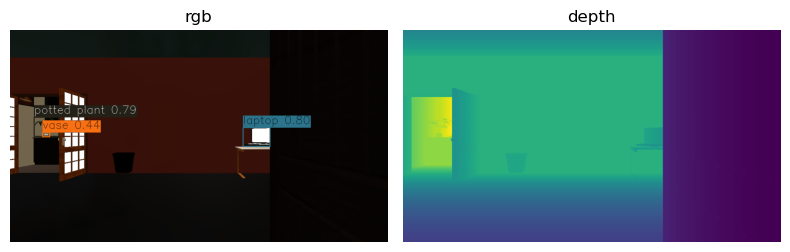

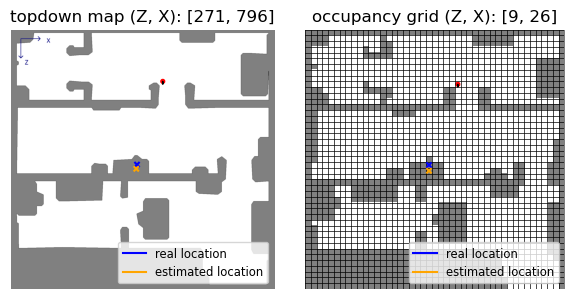


Target object <laptop> found after 143 actions!
Found location: [    -7.0854    0.026859      7.2838]
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 143
Travelled distance: 32.30 m
Computed location error: 0.227 m


In [8]:
for index, (GRID_POSITION, AGENT_YAW) in enumerate(zip(starting_grid_positions, starting_orientations)):

    # Initialize belief map: NUM_CLASSES + 1 for the background 
    belief_map = [[np.ones(NUM_CLASSES + 1) * DIRICHLET_PRIOR for _ in range(grid_resolution[1])] for _ in range(grid_resolution[0])]

    # Initialize an agent
    agent = sim.initialize_agent(sim_settings["default_agent"])

    # Sample a random position (within the possible ones)
    grid_position = GRID_POSITION
    idx = grid_free_cells.index(grid_position)
    world_position = world_free_coords[idx]
    map_position = map_free_cells[idx]

    # Sample a random yaw rotation
    agent_yaw = AGENT_YAW
    agent_quart = myutils.yaw_to_quaternion(agent_yaw)

    # Set agent state
    agent_state = habitat_sim.AgentState()
    agent_state.position = world_position
    agent_state.rotation = agent_quart
    agent.set_state(agent_state)

    # Compute agent radius in both maps
    min_bounds, max_bounds = sim.pathfinder.get_bounds()
    x_dim = max_bounds[0] - min_bounds[0]
    topdown_radius = (AGENT_RADIUS / x_dim * topdown_resolution[0])
    grid_radius = (AGENT_RADIUS / x_dim * grid_resolution[0])

    # Get initial agent position tuple and radius tuple
    agent_radius = (topdown_radius, grid_radius)
    agent_positions = (map_position, grid_position)

    # Metrics init
    target_found = False
    num_actions = 0
    travelled_distance = 0.0
    location_error = float("inf")

    # Simulation parameters
    num_clusters = simtools.num_cluster_centers(num_free_cells, max_clusters=num_free_cells)
    w_e, w_d, w_p = 0.4, 0.5, 0.1  # Weights for entropy, distance, and target probability
    MAX_ITER = int(num_free_cells * MAX_ITER_COEF)  # Maximum number of actions to perform

    # Print simulation 
    print(f"\nSimulation {index+1}/{len(starting_grid_positions)}")

    # Main simulation loop
    while (num_clusters <= num_free_cells) and (num_actions < MAX_ITER) and (not target_found):
        
        # Cluster grid map
        cluster_map = simtools.cluster_mapping(grid_free_cells, num_clusters)
        cluster_centers = simtools.get_cluster_centers(cluster_map, num_clusters)
        centroids = cluster_centers.copy() # For displaying logic
        cluster_occ_cells_map = simtools.assign_cluster_centers_to_cells(grid_occ_cells, cluster_centers, grid_free_cells)

        # Entropy map
        entropy_map = simtools.compute_entropy_map(belief_map, grid_map)

        # Plot occupancy grid with robot position
        plt.figure(figsize=(12,12))
        ax2 = plt.gca()
        ax2.imshow(grid_map)
        # Black grid lines
        rows, cols = grid_map.shape[:2]
        for i in range(rows):
            ax2.axhline(y=i-0.5, color='black', linewidth=0.5)
        for j in range(cols):
            ax2.axvline(x=j-0.5, color='black', linewidth=0.5)

        # Plot each cluster with a different color in occupancy grid
        for i in range(len(centroids)):
            cluster_coords = [coord for coord, label in cluster_map.items() if label == i]
            if cluster_coords:
                x_coords, y_coords = zip(*cluster_coords)
                ax2.scatter(y_coords, x_coords, label=f'Cluster {i}', alpha=0.3)

        # Plot cluster centers
        for i, center in enumerate(centroids):
            ax2.scatter(center[1], center[0], marker='x', color='black', s=100, label=f'Center {i}', alpha=0.5)

        # Draw the agent position and orientation on the top-down map and occupancy grid
        grid_x, grid_y = grid_position
        ax2.add_patch(plt.Circle((grid_y, grid_x), grid_radius*2/3, color="red", fill=True))
        ax2.add_patch(plt.Arrow(grid_y, grid_x, -grid_radius * np.sin(math.radians(agent_yaw)), -grid_radius * np.cos(math.radians(agent_yaw)), width=grid_radius / 2, color="black"))

        # Save figure
        plt.savefig(f"outputs/image_{num_actions}.png")
        plt.close()

        # Plot entropy map
        fig = plt.figure(figsize=(12,12))
        ax3 = plt.gca()

        # Mask the zero entries
        entropy_map = simtools.compute_entropy_map(belief_map, grid_map)
        masked_entropy = np.ma.masked_where(entropy_map == 0, entropy_map)

        # Modify 'Reds' to avoid starting at white
        reds = plt.cm.get_cmap('Reds', 256)
        new_colors = reds(np.linspace(0.2, 1, 256))  # Start at 0.2 to avoid white
        custom_cmap = mcolors.ListedColormap(new_colors)
        custom_cmap.set_bad(color='white')  # Keep masked values white

        # Compute maximum entropy value in the masked entropy map
        max_entropy_value = max(np.max(masked_entropy), MAX_ENTROPY)
        min_entropy_value = min(np.min(masked_entropy), MIN_ENTROPY)

        # Add a colorbar for the entropy scale
        img = ax3.imshow(masked_entropy, cmap=custom_cmap, interpolation='nearest', vmin=min_entropy_value, vmax=max_entropy_value)
        # Black grid lines
        rows, cols = grid_map.shape[:2]
        for i in range(rows):
            ax3.axhline(y=i-0.5, color='black', linewidth=0.5)
        for j in range(cols):
            ax3.axvline(x=j-0.5, color='black', linewidth=0.5)
        ax3.set_title('Entropy Map')
        ax3.axis('off')
        cbar = fig.colorbar(img, ax=ax3)
        cbar.set_label('Entropy')

        # Save figure
        plt.savefig(f"outputs/entropy_map_{num_actions}.png")
        plt.close()

        # Transversed cells and entropy values
        transversed_cells.append(grid_position)

        # Compute average entropy value across entropy map on ocupied cells
        average_entropy = np.mean(masked_entropy)
        entropy_values.append(average_entropy)

        # Display the simulation state
        #simtools.display_topdown_and_entropy_maps(topdown_map, grid_map, entropy_map, cluster_map, centroids, agent_positions, agent_radius, agent_yaw)

        # Move into each cluster center
        while (cluster_centers) and (num_actions < MAX_ITER) and (not target_found):

            # Computes scores for each cluster center
            distances, avg_entropies, avg_target_probs = [], [], []
            for cluster_center in cluster_centers:
                # Path distance 
                distance, _ = simtools.compute_path(grid_position, cluster_center, grid_free_cells)
                distances.append(distance)

                # Average entropy of the cluster
                avg_entropy = simtools.compute_average_entropy(belief_map, cluster_occ_cells_map[tuple(cluster_center)])
                avg_entropies.append(avg_entropy)

                # Target probability in the cluster surroundings
                avg_target_prob = simtools.compute_max_target_probability(belief_map, cluster_occ_cells_map[tuple(cluster_center)], indoor_objects.index(TARGET_OBJECT))
                avg_target_probs.append(avg_target_prob)

            # Normalize score components
            distances, avg_entropies, avg_target_probs = np.array(distances), np.array(avg_entropies), np.array(avg_target_probs)
            distances = (distances-np.min(distances)) / (np.max(distances)-np.min(distances)) if np.max(distances) != np.min(distances) else np.zeros_like(distances)
            avg_entropies = (avg_entropies-np.min(avg_entropies)) / (np.max(avg_entropies)-np.min(avg_entropies)) if abs(np.max(avg_entropies) - np.min(avg_entropies)) > 1e-5 else np.zeros_like(avg_entropies)
            avg_target_probs = (avg_target_probs-np.min(avg_target_probs)) / (np.max(avg_target_probs)-np.min(avg_target_probs)) if np.max(avg_target_probs) != np.min(avg_target_probs) else np.zeros_like(avg_target_probs)

            # Select best cluster center based on the scores
            scores = w_e * avg_entropies + w_d * (1-distances) + w_p * avg_target_probs
            max_score_idx = np.argmax(scores)
            cluster_center = cluster_centers[max_score_idx]
            _, path = simtools.compute_path(grid_position, cluster_center, grid_free_cells)

            # Move through the path
            while (path) and (num_actions < MAX_ITER) and (not target_found):
                
                # Compute actions to move to next path cell
                action_list = simtools.compute_relative_actions(grid_position, agent_yaw, path[0], ACTIONS)

                # Perform the rotation action, if needed
                for action in action_list:

                    # Perform action
                    grid_position, agent_yaw = simtools.perform_action(action, grid_position, agent_yaw)
                    idx = grid_free_cells.index(grid_position)
                    map_position, world_position = map_free_cells[idx], world_free_coords[idx]
                    agent_positions = (map_position, grid_position)
                    agent_quart = myutils.yaw_to_quaternion(agent_yaw)

                    # Update metrics
                    num_actions += 1
                    travelled_distance += simtools.compute_travelled_distance(agent_state.position, world_position)

                    # Update agent state
                    agent_state.position = world_position
                    agent_state.rotation = agent_quart
                    agent.set_state(agent_state)

                    # Get observations
                    obs = sim.get_sensor_observations(0)
                    rgb, depth = obs["color_sensor"], obs["depth_sensor"]

                    # YOLO Prediction
                    results = yolo_model.predict(source=rgb[:,:,:3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
                    detections = simtools.parse_yolo_detections(results)
                    simtools.merge_rgb_yolo_outputs(rgb, detections)
                    target_found, target_bbox = simtools.was_target_found(TARGET_OBJECT_ID, detections, CONFIDENCE_THRESHOLD)
                    
                    # Initialize processed cells
                    processed_cells = []

                    # Process the observations
                    for det in detections:
                        box, class_id, confidence, name, prob_vector = itemgetter('box', 'class_id', 'confidence', 'name', 'prob_vector')(det)
                        scale = myutils.compute_bbox_scale(box, rgb)

                        # Center of bbox and depth value
                        center_x, center_y = simtools.get_box_center(box)
                        depth_value = depth[center_y, center_x]

                        # Project to real world, grid and map coords
                        camera_world_position = simtools.get_camera_pos_from_agent_pos(world_position, AGENT_HEIGHT)
                        object_position = simtools.compute_real_world_position_from_pixel(camera_world_position, agent_quart, depth_value, center_x, center_y, intrinsics)
                        object_map_position, object_grid_position = simtools.get_2d_coords(object_position, topdown_resolution, grid_resolution, sim.pathfinder)

                        # Check if projected cell is outside free grid cells
                        if object_grid_position in grid_free_cells:
                            object_grid_position = simtools.get_closest_grey_cell(tuple(object_grid_position), grid_map)

                        # Add this cell to processed cells
                        if tuple(object_grid_position) not in processed_cells:
                            processed_cells.append(tuple(object_grid_position))

                        # Likelihood vector: likelihood of each class (Rule 1)
                        likelihood_vector = probtools.compute_likelihood_vector(prob_vector, scale, dirichlet_priors, classes_bins)

                        # Kaplan Update to the belief map in that cell
                        grid_x, grid_y = object_grid_position
                        belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

                    # Compute every theoretically visible occupied cell
                    rays = simtools.simulate_visibility_rays(grid_map, grid_position, agent_yaw)
                    visible_occ_cells = simtools.compute_visible_occ_cells(rays, grid_map, depth, grid_cells, world_coords, grid_position, agent_state.rotation, intrinsics)
                
                    # Go through every visible occupied cell and update the belief map
                    for cell in visible_occ_cells:
                        if tuple(cell) not in processed_cells:

                            # Compute distance to the cell
                            grid_x, grid_y = cell
                            distance = np.linalg.norm((np.array(grid_position) - np.array([grid_x, grid_y]))* CELL_SIDE)

                            # Compute the likelihood vector for the cell (Rule 2)
                            likelihood_vector = probtools.compute_background_likelihood_vector(distance, NUM_CLASSES)

                            # Kaplan update to the belief map in that cell
                            belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

                    # Entropy map
                    entropy_map = simtools.compute_entropy_map(belief_map, grid_map)


                    # Plot occupancy grid with robot position
                    plt.figure(figsize=(12,12))
                    ax2 = plt.gca()
                    ax2.imshow(grid_map)
                    # Black grid lines
                    rows, cols = grid_map.shape[:2]
                    for i in range(rows):
                        ax2.axhline(y=i-0.5, color='black', linewidth=0.5)
                    for j in range(cols):
                        ax2.axvline(x=j-0.5, color='black', linewidth=0.5)

                    # Plot each cluster with a different color in occupancy grid
                    for i in range(len(centroids)):
                        cluster_coords = [coord for coord, label in cluster_map.items() if label == i]
                        if cluster_coords:
                            x_coords, y_coords = zip(*cluster_coords)
                            ax2.scatter(y_coords, x_coords, label=f'Cluster {i}', alpha=0.3)

                    # Plot cluster centers
                    for i, center in enumerate(centroids):
                        ax2.scatter(center[1], center[0], marker='x', color='black', s=100, label=f'Center {i}', alpha=0.5)

                    # Draw the agent position and orientation on the top-down map and occupancy grid
                    grid_x, grid_y = grid_position
                    ax2.add_patch(plt.Circle((grid_y, grid_x), grid_radius*2/3, color="red", fill=True))
                    ax2.add_patch(plt.Arrow(grid_y, grid_x, -grid_radius * np.sin(math.radians(agent_yaw)), -grid_radius * np.cos(math.radians(agent_yaw)), width=grid_radius / 2, color="black"))

                    # Save figure
                    plt.savefig(f"outputs/image_{num_actions}.png")
                    plt.close()

                    # Plot entropy map
                    fig = plt.figure(figsize=(12,12))
                    ax3 = plt.gca()

                    # Mask the zero entries
                    entropy_map = simtools.compute_entropy_map(belief_map, grid_map)
                    masked_entropy = np.ma.masked_where(entropy_map == 0, entropy_map)

                    # Modify 'Reds' to avoid starting at white
                    reds = plt.cm.get_cmap('Reds', 256)
                    new_colors = reds(np.linspace(0.2, 1, 256))  # Start at 0.2 to avoid white
                    custom_cmap = mcolors.ListedColormap(new_colors)
                    custom_cmap.set_bad(color='white')  # Keep masked values white

                    # Compute maximum entropy value in the masked entropy map
                    max_entropy_value = max(np.max(masked_entropy), MAX_ENTROPY)
                    min_entropy_value = min(np.min(masked_entropy), MIN_ENTROPY)

                    # Add a colorbar for the entropy scale
                    img = ax3.imshow(masked_entropy, cmap=custom_cmap, interpolation='nearest', vmin=min_entropy_value, vmax=max_entropy_value)
                    # Black grid lines
                    rows, cols = grid_map.shape[:2]
                    for i in range(rows):
                        ax3.axhline(y=i-0.5, color='black', linewidth=0.5)
                    for j in range(cols):
                        ax3.axvline(x=j-0.5, color='black', linewidth=0.5)
                    ax3.set_title('Entropy Map')
                    ax3.axis('off')
                    cbar = fig.colorbar(img, ax=ax3)
                    cbar.set_label('Entropy')

                    # Save figure
                    plt.savefig(f"outputs/entropy_map_{num_actions}.png")
                    plt.close()

                    # Transversed cells and entropy values
                    transversed_cells.append(grid_position)

                    # Compute average entropy value across entropy map on ocupied cells
                    average_entropy = np.mean(masked_entropy)
                    entropy_values.append(average_entropy)








                    # Check if the target object was found in the belief map
                    if not target_found:
                        target_found, target_grid_position = simtools.check_target_probability_in_entropy_map(belief_map, grid_cells, TARGET_OBJECT_CLASS_ID, PSEUDO_COUNT_THRESHOLD)
                        
                    # Check if target was found
                    if target_found: break
                
                # Check if target was found
                if target_found: break

                # Remove the path cell
                path.pop(0)

            # Check if target was found
            if target_found: break

            # When in cluster center, rotate 3 times to get the full 360 degrees view
            #simtools.display_sim_observations(rgb, depth)
            #simtools.display_topdown_and_entropy_maps(topdown_map, grid_map, entropy_map, cluster_map, centroids, agent_positions, agent_radius, agent_yaw)
            for i in range(3):
                grid_position, agent_yaw = simtools.perform_action('turn_right', grid_position, agent_yaw)
                agent_quart = myutils.yaw_to_quaternion(agent_yaw)
                agent_state.rotation = agent_quart
                agent.set_state(agent_state)

                # Update metrics
                num_actions += 1

                # Get observations
                observations = sim.get_sensor_observations(0)
                rgb = observations["color_sensor"]
                depth = observations["depth_sensor"]

                # YOLO Prediction
                results = yolo_model.predict(source=rgb[:,:,:3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
                detections = simtools.parse_yolo_detections(results)
                simtools.merge_rgb_yolo_outputs(rgb, detections)
                target_found, target_bbox = simtools.was_target_found(TARGET_OBJECT_ID, detections, CONFIDENCE_THRESHOLD)

                # Initialize processed cells
                processed_cells = []

                # Process the observations
                for det in detections:
                    box, class_id, confidence, name, prob_vector = itemgetter('box', 'class_id', 'confidence', 'name', 'prob_vector')(det)
                    scale = myutils.compute_bbox_scale(box, rgb)

                    # Center of bbox and depth value
                    center_x, center_y = simtools.get_box_center(box)
                    depth_value = depth[center_y, center_x]

                    # Project to real world, grid and map coords
                    camera_world_position = simtools.get_camera_pos_from_agent_pos(world_position, AGENT_HEIGHT)
                    object_position = simtools.compute_real_world_position_from_pixel(camera_world_position, agent_quart, depth_value, center_x, center_y, intrinsics)
                    object_map_position, object_grid_position = simtools.get_2d_coords(object_position, topdown_resolution, grid_resolution, sim.pathfinder)

                    # Check if projected cell is outside free grid cells
                    if object_grid_position in grid_free_cells:
                        object_grid_position = simtools.get_closest_grey_cell(tuple(object_grid_position), grid_map)

                    # Add this cell to processed cells
                    if tuple(object_grid_position) not in processed_cells:
                        processed_cells.append(tuple(object_grid_position))

                    # Likelihood vector: likelihood of each class (Rule 1)
                    likelihood_vector = probtools.compute_likelihood_vector(prob_vector, scale, dirichlet_priors, classes_bins)

                    # Kaplan Update to the belief map in that cell
                    grid_x, grid_y = object_grid_position
                    belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

                # Compute every theoretically visible occupied cell
                rays = simtools.simulate_visibility_rays(grid_map, grid_position, agent_yaw)
                visible_occ_cells = simtools.compute_visible_occ_cells(rays, grid_map, depth, grid_cells, world_coords, grid_position, agent_state.rotation, intrinsics)

                # Go through every visible occupied cell and update the belief map
                for cell in visible_occ_cells:
                    if tuple(cell) not in processed_cells:

                        # Compute distance to the cell
                        grid_x, grid_y = cell
                        distance = np.linalg.norm((np.array(grid_position) - np.array([grid_x, grid_y]))* CELL_SIDE)

                        # Compute the likelihood vector for the cell (Rule 2)
                        likelihood_vector = probtools.compute_background_likelihood_vector(distance, NUM_CLASSES)

                        # Kaplan update to the belief map in that cell
                        belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)


                # Plot occupancy grid with robot position
                plt.figure(figsize=(12,12))
                ax2 = plt.gca()
                ax2.imshow(grid_map)
                # Black grid lines
                rows, cols = grid_map.shape[:2]
                for i in range(rows):
                    ax2.axhline(y=i-0.5, color='black', linewidth=0.5)
                for j in range(cols):
                    ax2.axvline(x=j-0.5, color='black', linewidth=0.5)

                # Plot each cluster with a different color in occupancy grid
                for i in range(len(centroids)):
                    cluster_coords = [coord for coord, label in cluster_map.items() if label == i]
                    if cluster_coords:
                        x_coords, y_coords = zip(*cluster_coords)
                        ax2.scatter(y_coords, x_coords, label=f'Cluster {i}', alpha=0.3)

                # Plot cluster centers
                for i, center in enumerate(centroids):
                    ax2.scatter(center[1], center[0], marker='x', color='black', s=100, label=f'Center {i}', alpha=0.5)

                # Draw the agent position and orientation on the top-down map and occupancy grid
                grid_x, grid_y = grid_position
                ax2.add_patch(plt.Circle((grid_y, grid_x), grid_radius*2/3, color="red", fill=True))
                ax2.add_patch(plt.Arrow(grid_y, grid_x, -grid_radius * np.sin(math.radians(agent_yaw)), -grid_radius * np.cos(math.radians(agent_yaw)), width=grid_radius / 2, color="black"))

                # Save figure
                plt.savefig(f"outputs/image_{num_actions}.png")
                plt.close()

                # Plot entropy map
                fig = plt.figure(figsize=(12,12))
                ax3 = plt.gca()

                # Mask the zero entries
                entropy_map = simtools.compute_entropy_map(belief_map, grid_map)
                masked_entropy = np.ma.masked_where(entropy_map == 0, entropy_map)

                # Modify 'Reds' to avoid starting at white
                reds = plt.cm.get_cmap('Reds', 256)
                new_colors = reds(np.linspace(0.2, 1, 256))  # Start at 0.2 to avoid white
                custom_cmap = mcolors.ListedColormap(new_colors)
                custom_cmap.set_bad(color='white')  # Keep masked values white

                # Compute maximum entropy value in the masked entropy map
                max_entropy_value = max(np.max(masked_entropy), MAX_ENTROPY)
                min_entropy_value = min(np.min(masked_entropy), MIN_ENTROPY)

                # Add a colorbar for the entropy scale
                img = ax3.imshow(masked_entropy, cmap=custom_cmap, interpolation='nearest', vmin=min_entropy_value, vmax=max_entropy_value)
                # Black grid lines
                rows, cols = grid_map.shape[:2]
                for i in range(rows):
                    ax3.axhline(y=i-0.5, color='black', linewidth=0.5)
                for j in range(cols):
                    ax3.axvline(x=j-0.5, color='black', linewidth=0.5)
                ax3.set_title('Entropy Map')
                ax3.axis('off')
                cbar = fig.colorbar(img, ax=ax3)
                cbar.set_label('Entropy')

                # Save figure
                plt.savefig(f"outputs/entropy_map_{num_actions}.png")
                plt.close()

                # Transversed cells and entropy values
                transversed_cells.append(grid_position)

                # Compute average entropy value across entropy map on ocupied cells
                average_entropy = np.mean(masked_entropy)
                entropy_values.append(average_entropy)








                # Check if the target object was found in the belief map
                if not target_found:
                    target_found, target_grid_position = simtools.check_target_probability_in_entropy_map(belief_map, grid_cells, TARGET_OBJECT_CLASS_ID, PSEUDO_COUNT_THRESHOLD)
                
                # Check if target was found
                if target_found: break 

            # Remove cluster center
            cluster_centers.remove(cluster_center)

        # Double the number of clusters if all clusters were visited
        num_clusters *= 2

    # Compute the target location if it was found
    if target_found:

        if target_grid_position is None: # Not found in the belief map
            # Real world position
            center_x, center_y = simtools.get_box_center(target_bbox)
            depth_value = depth[center_y, center_x]
            target_location = simtools.compute_real_world_position_from_pixel(agent_state.position, agent_state.rotation, depth_value, center_x, center_y, intrinsics)
        else:
            # Real world position from grid position
            target_location = world_coords[grid_cells.index(target_grid_position)]

    # Evaluating correctness of the target detection
    if target_found:
        # Location error
        location_error = simtools.compute_location_error(target_location, REAL_TARGET_LOCATION)

        # Compare with threshold
        if location_error > LOCATION_ERROR_THRESHOLD:
            print(f"\nLocation error {location_error:.3f} m exceeds threshold {LOCATION_ERROR_THRESHOLD} m. FAILURE!")
            target_found = False

        # Plot maps with target
        target_positions = simtools.get_2d_coords(target_location, topdown_resolution, grid_resolution, sim.pathfinder)
        real_target_positions = simtools.get_2d_coords(REAL_TARGET_LOCATION, topdown_resolution, grid_resolution, sim.pathfinder)
        simtools.display_sim_observations(rgb, depth)
        simtools.display_topdown_maps_with_target(topdown_map, grid_map, agent_positions, agent_radius, agent_yaw, target_positions, real_target_positions)

    # Display simulation result and metrics
    if target_found:
        print(f"\nTarget object <{TARGET_OBJECT}> found after {num_actions} actions!")
        print(f"Found location: {target_location}")
    else:
        print(f"\nTarget object <{TARGET_OBJECT}> not found after {num_actions} actions!")

    print(f"Ground-truth location: {REAL_TARGET_LOCATION}")
    print(f"Number of actions: {num_actions}")
    print(f"Travelled distance: {travelled_distance:.2f} m")
    print(f"Computed location error: {location_error:.3f} m")

    # Append metrics to epochs
    num_actions_epochs.append(num_actions)
    travelled_distance_epochs.append(travelled_distance)
    success_epochs.append(target_found)
    location_error_epochs.append(location_error)

In [10]:
# Plot occupancy grid with robot position
plt.figure(figsize=(12,12))
ax2 = plt.gca()
ax2.imshow(grid_map)
# Black grid lines
rows, cols = grid_map.shape[:2]
for i in range(rows):
    ax2.axhline(y=i-0.5, color='black', linewidth=0.5)
for j in range(cols):
    ax2.axvline(x=j-0.5, color='black', linewidth=0.5)

# Plot each cluster with a different color in occupancy grid
for i in range(len(centroids)):
    cluster_coords = [coord for coord, label in cluster_map.items() if label == i]
    if cluster_coords:
        x_coords, y_coords = zip(*cluster_coords)
        ax2.scatter(y_coords, x_coords, label=f'Cluster {i}', alpha=0.3)

# Plot cluster centers
for i, center in enumerate(centroids):
    ax2.scatter(center[1], center[0], marker='x', color='black', s=100, label=f'Center {i}', alpha=0.5)

# Draw the agent position and orientation on the top-down map and occupancy grid
grid_x, grid_y = grid_position
ax2.add_patch(plt.Circle((grid_y, grid_x), grid_radius*2/3, color="red", fill=True))
ax2.add_patch(plt.Arrow(grid_y, grid_x, -grid_radius * np.sin(math.radians(agent_yaw)), -grid_radius * np.cos(math.radians(agent_yaw)), width=grid_radius / 2, color="black"))


target_grid_position = sim


occ_grid_radius = grid_radius * 4/2

# Draw target location
if target_found:
    _, target_grid_position = simtools.get_2d_coords(REAL_TARGET_LOCATION, topdown_resolution, grid_resolution, sim.pathfinder)
    target_pos_grid = target_grid_position
    target_grid_x, target_grid_y = target_grid_position
    ax2.plot([target_pos_grid[1] - occ_grid_radius*2/3, target_pos_grid[1] + occ_grid_radius*2/3],
        [target_pos_grid[0] + occ_grid_radius*2/3, target_pos_grid[0] - occ_grid_radius*2/3], color='red', linewidth=3)
    ax2.plot([target_pos_grid[1] - occ_grid_radius*2/3, target_pos_grid[1] + occ_grid_radius*2/3],
        [target_pos_grid[0] - occ_grid_radius*2/3, target_pos_grid[0] + occ_grid_radius*2/3], color='red', linewidth=3)

print("target_grid_position:", target_grid_position)
# Save figure
plt.savefig(f"outputs/image_{num_actions}.png")
plt.close()

target_grid_position: [23, 21]


In [11]:
# Make sure OpenCV is installed:  pip install opencv-python

import cv2
import os

input_dir = "outputs"           # where your 214×2 images live
output_video = "side_by_side.mp4"
fps = 5
extra_seconds_at_end = 10
extra_frames = extra_seconds_at_end * fps   # 150 frames

# Collect valid (image_i, entropy_map_i) pairs
frames = []
i = 0
while True:
    left = os.path.join(input_dir, f"image_{i}.png")
    right = os.path.join(input_dir, f"entropy_map_{i}.png")
    if not (os.path.exists(left) and os.path.exists(right)):
        break
    frames.append((left, right))
    i += 1

if not frames:
    raise RuntimeError("No valid (image_i, entropy_map_i) pairs detected!")

# Read first pair to determine frame size
imgL = cv2.imread(frames[0][0])
imgR = cv2.imread(frames[0][1])
h, w, _ = imgL.shape
assert imgR.shape[:2] == (h, w), "Left & right image must have equal size"

frame_size = (w * 2, h)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(output_video, fourcc, fps, frame_size)

for left_path, right_path in frames:
    L = cv2.imread(left_path)
    R = cv2.imread(right_path)
    R = cv2.resize(R, (w, h))
    concat = cv2.hconcat([L, R])
    writer.write(concat)

# Freeze final frame for extra 7s
last_concat = cv2.hconcat([
    cv2.imread(frames[-1][0]),
    cv2.resize(cv2.imread(frames[-1][1]), (w, h))
])
for _ in range(extra_frames):
    writer.write(last_concat)

writer.release()
print(f"✅ Done — wrote {len(frames)} frames + {extra_frames} frozen, to {output_video} at {fps} fps")


✅ Done — wrote 144 frames + 50 frozen, to side_by_side.mp4 at 5 fps


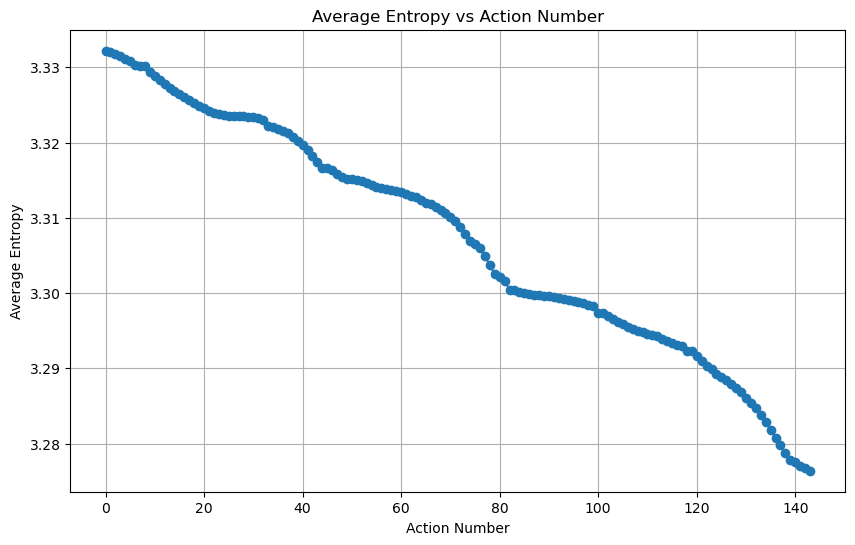

In [19]:
# Entropy vs action number plot
plt.figure(figsize=(10,6))
plt.plot(range(len(entropy_values)), entropy_values, marker='o')
# Set y labels limits
plt.title('Average Entropy vs Action Number')
plt.xlabel('Action Number')
plt.ylabel('Average Entropy')
plt.grid()
plt.savefig("outputs/entropy_vs_actions.png")

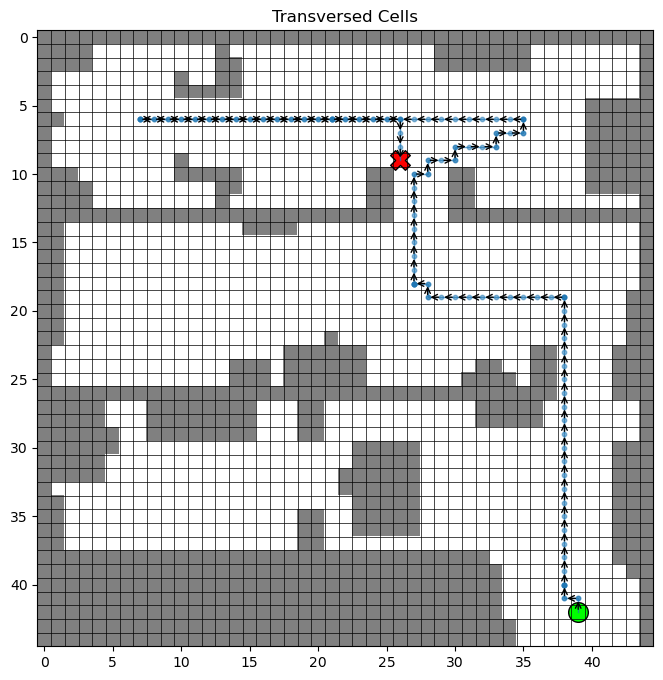

In [13]:
plt.figure(figsize=(8,8))
ax = plt.gca()
ax.imshow(grid_map)

# Black grid lines
rows, cols = grid_map.shape[:2]
for i in range(rows):
    ax.axhline(y=i-0.5, color='black', linewidth=0.5)
for j in range(cols):
    ax.axvline(x=j-0.5, color='black', linewidth=0.5)

# Plot transversed cells
if transversed_cells:
    x_coords, y_coords = zip(*transversed_cells)

    # normal path points
    ax.scatter(y_coords, x_coords, s=10, alpha=0.5)

    # trajectory direction (line)
    ax.plot(y_coords, x_coords, linewidth=1, alpha=0.7)

    # highlight start + end
    ax.scatter(y_coords[0], x_coords[0], s=200, marker='o', edgecolor='black', facecolor='lime', label='start')
    ax.scatter(y_coords[-1], x_coords[-1], s=200, marker='X', edgecolor='black', facecolor='red', label='end')

    # optional arrows between each step (uncomment if you want them)
    for (x1,y1), (x2,y2) in zip(transversed_cells[:-1], transversed_cells[1:]):
        ax.annotate('', xy=(y2,x2), xytext=(y1,x1), arrowprops=dict(arrowstyle='->', lw=1))

ax.set_title('Transversed Cells')
plt.savefig("outputs/transversed_cells.png")

In [ ]:
import numpy as np

# Pre-process
num_actions_epochs = np.array(num_actions_epochs)
travelled_distance_epochs = np.array(travelled_distance_epochs)
success_epochs = np.array(success_epochs)
location_error_epochs = np.array(location_error_epochs)

# Counting
num_total_epochs = len(num_actions_epochs)
num_success_epochs = np.sum(success_epochs)

# Metrics on all runs
total_avg_num_actions = np.sum(num_actions_epochs) / num_total_epochs
total_avg_tavelled_distance = np.sum(travelled_distance_epochs) / num_total_epochs
success_rate = num_success_epochs / num_total_epochs * 100

# Metrics on successful runs
success_avg_travelled_distance = np.sum(travelled_distance_epochs[success_epochs]) / num_success_epochs
success_avg_num_actions = np.sum(num_actions_epochs[success_epochs]) / num_success_epochs
success_avg_location_error = np.sum(location_error_epochs[success_epochs]) / num_success_epochs

#Print final metrics
print("\n\nMETRICS:\n")
print(f"Total number of epochs: {num_total_epochs}")
print(f"Number of successful epochs: {num_success_epochs}")
print(f"Success rate: {success_rate:.2f}%")
print(f"Average number of actions (epochs): {total_avg_num_actions:.2f}")
print(f"Average travelled distance (epochs): {total_avg_tavelled_distance:.2f} m")
print(f"Average success rate (epochs): {success_rate:.2f}%")
print(f"\nAverage number of actions (successful epochs): {success_avg_num_actions:.2f}")
print(f"Average travelled distance (successful epochs): {success_avg_travelled_distance:.2f} m")
print(f"Average location error (successful epochs): {success_avg_location_error:.3f} m")

# Number of actions max, min and std
print(f"\nMax number of actions (epochs): {np.max(num_actions_epochs)}")
print(f"Min number of actions (epochs): {np.min(num_actions_epochs)}")
print(f"Std number of actions (epochs): {np.std(num_actions_epochs)}")    

In [ ]:
metrics_file = 'results/metrics.json'

# Load existing metrics if the file exists, otherwise start with an empty list
if os.path.exists(metrics_file):
    with open(metrics_file, 'r') as f:
        existing_metrics = json.load(f)
else:
    existing_metrics = []

# New metrics entry (convert numpy types to native Python types)
def to_python_type(val):
    if hasattr(val, "item"):
        return val.item()
    return val

new_metrics = {
    "simulation_index": to_python_type(INDEX),
    "scene": SCENE,
    "target_object": TARGET_OBJECT,
    "search_method": METHOD,
    "confidence_threshold": to_python_type(CONFIDENCE_THRESHOLD),
    "max_iter_coefficient": to_python_type(MAX_ITER_COEF),
    "location_error_threshold": to_python_type(LOCATION_ERROR_THRESHOLD),
    "pseudo_count_threshold": to_python_type(PSEUDO_COUNT_THRESHOLD),
    "num_total_epochs": to_python_type(num_total_epochs),
    "num_success_epochs": to_python_type(num_success_epochs),
    "success_rate": to_python_type(success_rate),
    "success_avg_num_actions": to_python_type(success_avg_num_actions),
    "success_avg_travelled_distance": to_python_type(success_avg_travelled_distance),
    "success_avg_location_error": to_python_type(success_avg_location_error),
}

# Check for duplicate (by simulation_index and search_method)
duplicate_exists = any(
    entry["simulation_index"] == new_metrics["simulation_index"] and
    entry["search_method"] == new_metrics["search_method"] 
    for entry in existing_metrics
)

if not duplicate_exists:
    existing_metrics.append(new_metrics)
else:
    print(f"Metrics for simulation_index {new_metrics['simulation_index']} and search_method '{new_metrics['search_method']}' already exist. Skipping append.")

# Save updated metrics list
with open(metrics_file, 'w') as f:
    json.dump(existing_metrics, f, indent=4)

print(f"\nMetrics saved to {metrics_file}")

In [ ]:
sim.close()